# Proyek Klasifikasi Gambar: Red Chili Pepper Pests
- **Nama:** Bagus Alfiyan Yusuf
- **Email:** dctbagalyus@gmail.com
- **ID Dicoding:** fiyanz

## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import tensorflowjs as tfjs
import subprocess

# Jika menggunakan Google Colab, uncomment:
# from google.colib import drive
# drive.mount('/content/drive')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-05-27 14:06:55.680633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779890815.872541      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779890815.926042      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779890816.391003      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779890816.391051      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779890816.391054      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [ ]:
# Path dataset - sesuaikan dengan lokasi dataset
DATASET_DIR = "/kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset"
# Jika menggunakan Colab, ubah path berikut:
# DATASET_DIR = "/content/drive/MyDrive/RedChiliPepperPestsDataset/"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = ['MP (kutu daun)', 'BT (kutu kebul)', 'T (thrips)', 'C (ulat)']
NUM_CLASSES = len(CLASS_NAMES)

# Mapping prefix filename ke class_id
CLASS_MAP = {
    'kutu-daun': 0,
    'kutu-kebul': 1,
    'thrips': 2,
    'thrips-baru': 2,
    'ulat': 3,
}


def get_class_from_filename(filename):
    """
    Turunkan class_id dari prefix filename.
    Fallback: baca class_id dari file label .txt jika prefix tidak dikenal.
    """
    basename = os.path.basename(filename)
    prefix = basename.split('--')[0].lower()

    if prefix in CLASS_MAP:
        return CLASS_MAP[prefix]

    # Fallbak: baca dari file label
    label_path = filename.rsplit('.', 1)[0] + '.txt'
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                return int(first_line.split()[0])

    raise ValueError(f"Tidak bisa menentukan kelas untuk: {filename}")


def collect_images_and_labels(image_dir):
    """Kumpulkan path gambar dan label dari sebuah direktori."""
    image_files = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
    labels = []
    valid_files = []
    for img_path in image_files:
        try:
            label = get_class_from_filename(img_path)
            labels.append(label)
            valid_files.append(img_path)
        except ValueError as e:
            print(f"Peringatan: {e}")

    return valid_files, labels


In [ ]:
# Kumpulkan data dari setiap split
print("Mengumpulkan data training")
train_files, train_labels = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'train', 'images')
)
print(f"Training: {len(train_files)} gambar")

In [ ]:
print("Mengumpulkan data validasi")
val_files_1, val_labels_1 = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'val', 'images')
)
val_files_2, val_labels_2 = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'val', 'valid', 'images')
)
val_files = val_files_1 + val_files_2
val_labels = val_labels_1 + val_labels_2
print(f"Validasi: {len(val_files)} gabungan ({len(val_files_1)} + {len(val_files_2)})")

In [ ]:
print("Mengumpulkan data test")
test_files, test_labels = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'test', 'images')
)
print(f"Test: {len(test_files)} gambar")

# Distribusi kelas
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nDistribusi {split_name}:")
    for cls_id, count in zip(unique, counts):
        print(f"  {CLASS_NAMES[cls_id]}: {count} ({count/len(labels)*100:.1f}%)")

### Data Preprocessing

#### Split Dataset

In [ ]:
# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name="data_augmentation")


def parse_image(file_path, label):
    """Baca, decode, dan normalisasi gambar."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label


def augment_image(image, label):
    """Terapkan data augmentation pada gambar."""
    image = data_augmentation(image)
    return image, label


def create_dataset(file_paths, labels, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=42)
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size) 
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)  # then augment
    ds = ds.prefetch(AUTOTUNE)
    return ds


In [ ]:
# Buat dataset untuk setiap split
train_ds = create_dataset(train_files, train_labels, shuffle=True, augment=True)
val_ds = create_dataset(val_files, val_labels, shuffle=False, augment=False)
test_ds = create_dataset(test_files, test_labels, shuffle=False, augment=False)

print(f"Train dataset: {len(train_files)} gambar")
print(f"Val dataset: {len(val_files)} gambar")
print(f"Test dataset: {len(test_files)} gambar")

In [ ]:
# Hitung class weights untuk menangani ketidakseimbangan kelas
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2, 3]),
    y=np.array(train_labels)
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights:")
for i, w in class_weight_dict.items():
    print(f"  {CLASS_NAMES[i]}: weight={w:.4f}")

In [ ]:
# Visualisasi contoh gambar training
plt.figure(figsize=(12, 8))
sample_images, sample_labels = next(iter(train_ds))
for i in range(min(16, len(sample_images))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(sample_images[i])
    label_idx = tf.argmax(sample_labels[i]).numpy()
    plt.title(CLASS_NAMES[label_idx], fontsize=9)
    plt.axis('off')
plt.suptitle('Contoh Gambar Training (dengan Augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

## Modelling

In [ ]:
def build_cnn_model(input_shape=(224, 224, 3), num_classes=4):
    """
    Bangun model CNN (tanpa pretrained weights).
    4 blok convolutional + classifier head.
    """
    inputs = keras.Input(shape=input_shape, name='input_image')

    # Data augmentation (hanya aktif saat training)
    x = data_augmentation(inputs)

    # Block 1: 32 filters
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2: 64 filters
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3: 128 filters
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4: 256 filters
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='pest_classifier_cnn')
    return model


# Bangun model
model = build_cnn_model(input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Tampilkan arsitektur
model.summary()

Model: "pest_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,836 (4.87 MB)

 Trainable params: 1,274,148 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


Epoch 1/100


E0000 00:00:1779891177.893266      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/pest_classifier_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779891182.710280     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.4052 - loss: 1.2468
Epoch 1: val_accuracy improved from -inf to 0.23848, saving model to best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 60s 430ms/step - accuracy: 0.4065 - loss: 1.2443 - val_accuracy: 0.2385 - val_loss: 11.4206 - learning_rate: 0.0010
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7454 - loss: 0.6199
Epoch 2: val_accuracy improved from 0.23848 to 0.29058, saving model to best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 362ms/step - accuracy: 0.7455 - loss: 0.6198 - val_accuracy: 0.2906 - val_loss: 6.5033 - learning_rate: 0.0010
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8265 - loss: 0.4316
Epoch 3: val_accuracy improved from 0.29058 to 0.33467, saving model to best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 360ms/step - accuracy: 0.8266 - loss: 0.4315 - val_accuracy: 0.3347 - val_loss: 7.2139 - learning_rate: 0.0010
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 309m

In [ ]:
# Training
EPOCHS = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

## Evaluasi dan Visualisasi

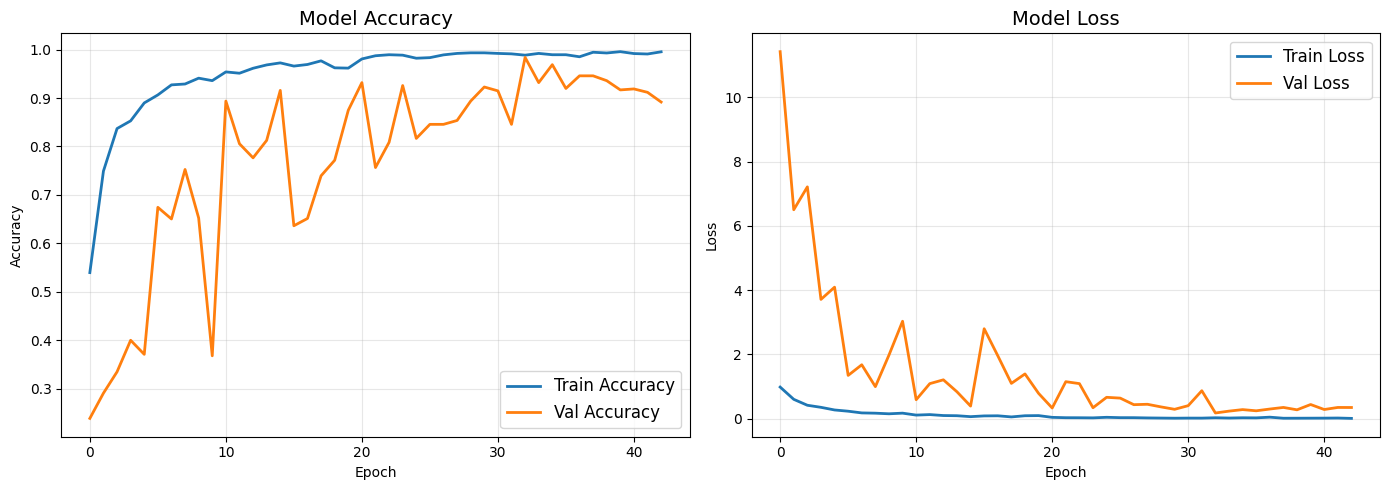


Final Train Accuracy: 0.9955
Final Val Accuracy: 0.8918
Best Val Accuracy: 0.9840


In [8]:
def plot_training_history(history):
    """Plot kurva accuracy dan loss selama training."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_training_history(history)

print(f"\nFinal Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")

=== Evaluasi pada Test Set ===

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step
=== Classification Report ===
                 precision    recall  f1-score   support

 MP (kutu daun)     1.0000    0.9219    0.9593        64
BT (kutu kebul)     0.9695    1.0000    0.9845       159
     T (thrips)     0.8364    1.0000    0.9109        46
       C (ulat)     1.0000    0.9593    0.9792       221

       accuracy                         0.9714       490
      macro avg     0.9515    0.9703    0.9585       490
   weighted avg     0.9747    0.9714    0.9719       490



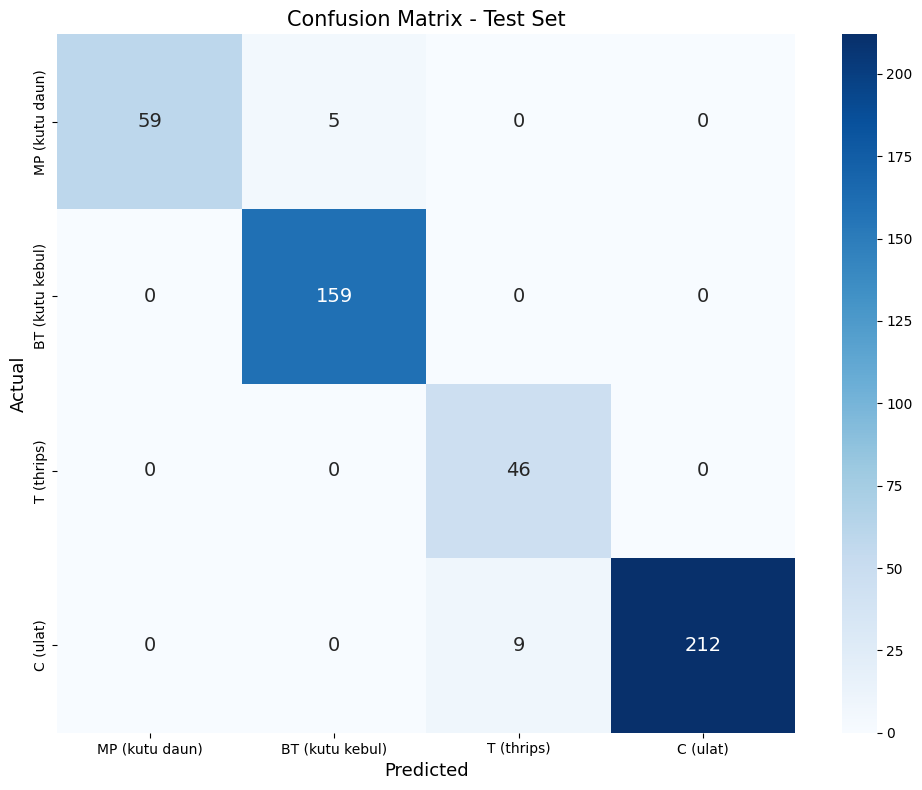


Test Accuracy: 0.9714 (476/490)


In [ ]:
# Evaluasi pada test set
print("Evaluasi pada Test Set\n")

# Load best model
best_model = keras.models.load_model('best_model.keras')

# Prediksi
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)

# Classification Report
print("Classification Report")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 14})
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix - Test Set', fontsize=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

test_accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({np.sum(y_pred == y_true)}/{len(y_true)})")

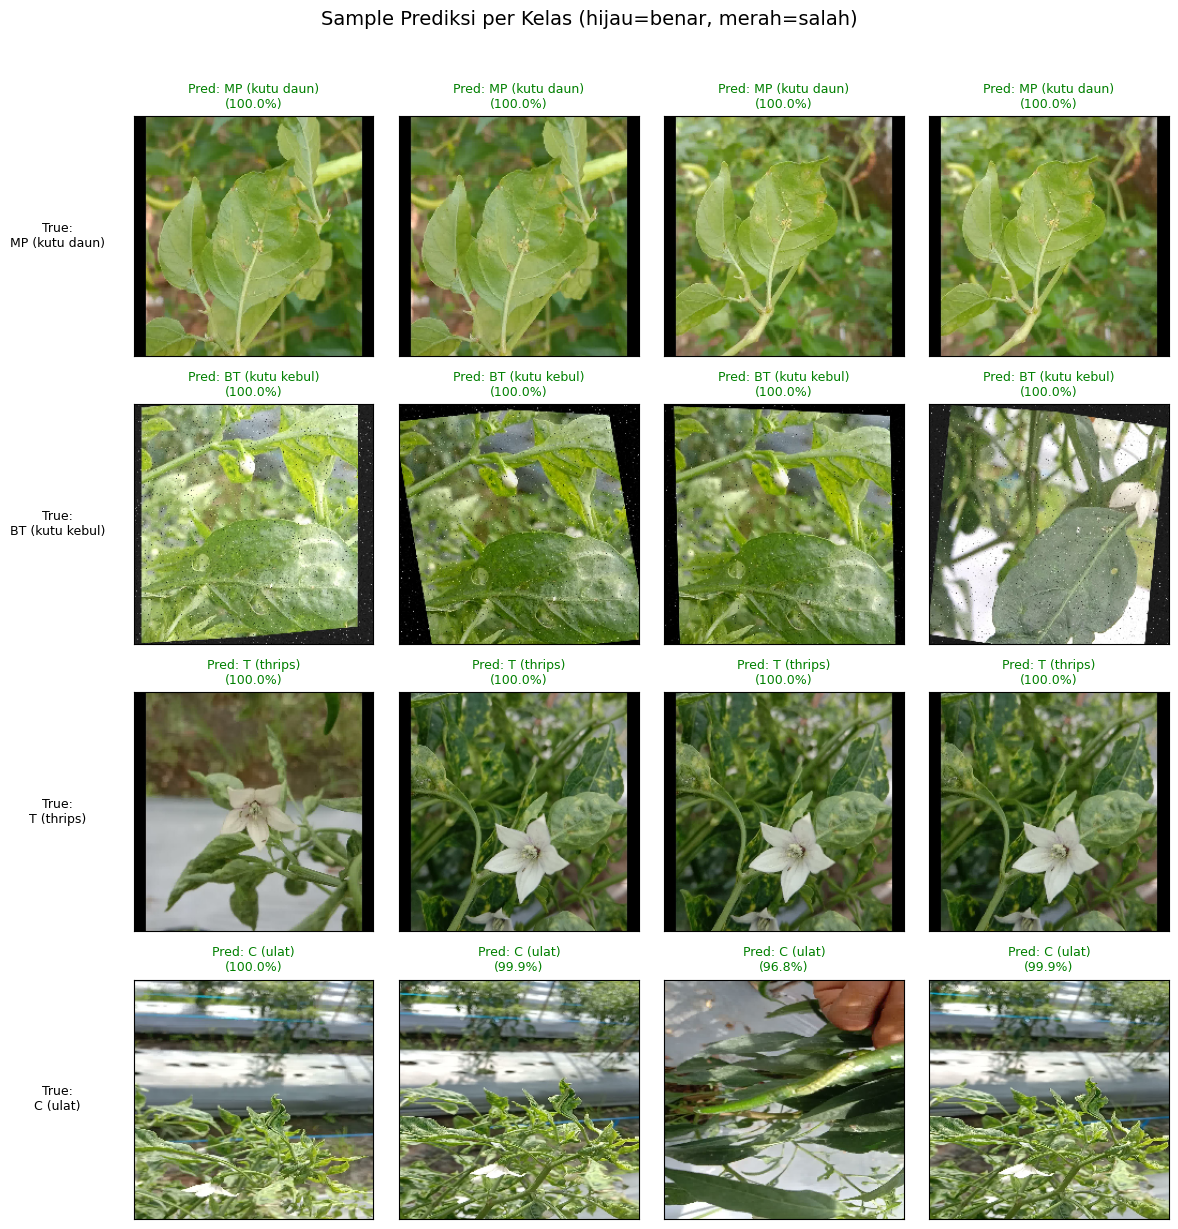

In [16]:
def show_sample_predictions(ds, class_names, n_per_class=4):
    """Tampilkan sample prediksi dengan minimal n sampel per kelas."""
    num_classes = len(class_names)
    
    # Kumpulkan sampel per kelas
    class_images = {i: [] for i in range(num_classes)}
    class_labels = {i: [] for i in range(num_classes)}
    class_preds  = {i: [] for i in range(num_classes)}

    for images, labels in ds:
        preds = best_model.predict(images, verbose=0)
        for i in range(len(images)):
            true_idx = tf.argmax(labels[i]).numpy()
            if len(class_images[true_idx]) < n_per_class:
                class_images[true_idx].append(images[i].numpy())
                class_labels[true_idx].append(true_idx)
                class_preds[true_idx].append(preds[i])
        # Stop kalau semua kelas sudah terpenuhi
        if all(len(v) >= n_per_class for v in class_images.values()):
            break

    # Plot: baris = kelas, kolom = sampel
    fig, axes = plt.subplots(num_classes, n_per_class, figsize=(n_per_class * 3, num_classes * 3))
    
    for row, class_idx in enumerate(range(num_classes)):
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(class_images[class_idx]):
                img   = class_images[class_idx][col]
                pred  = class_preds[class_idx][col]
                pred_idx    = np.argmax(pred)
                confidence  = np.max(pred) * 100
                true_label  = class_names[class_idx]
                pred_label  = class_names[pred_idx]
                color = 'green' if true_label == pred_label else 'red'
                ax.imshow(img)
                ax.set_title(
                    f"Pred: {pred_label}\n({confidence:.1f}%)",
                    color=color, fontsize=9
                )
                # Label baris di kolom pertama
                if col == 0:
                    ax.set_ylabel(
                        f"True:\n{true_label}",
                        fontsize=9, rotation=0,
                        labelpad=55, va='center'
                    )
            else:
                ax.axis('off')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle('Sample Prediksi per Kelas (hijau=benar, merah=salah)',fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_predictions(test_ds, CLASS_NAMES, n_per_class=4)

## Konversi Model

In [ ]:
# Load model terbaik
best_model = keras.models.load_model('best_model.keras')

# Simpan ke SavedModel (.pb)
best_model.export('saved_model/pest_classifier')

print("SavedModel (.pb) tersimpan di: saved_model/pest_classifier/")


In [ ]:
# Konversi ke TFLite (float32)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = '../tflite/model_pest_classification.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite model (float32): {tflite_path}")
print(f"Ukuran: {len(tflite_model) / 1024 / 1024:.2f} MB")

In [ ]:
# Konversi ke TFLite Quantized (float16)
converter_quant = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant.target_spec.supported_types = [tf.float16]
tflite_quant_model = converter_quant.convert()

tflite_quant_path = '../tflite/model_pest_classification_quantized.tflite'
with open(tflite_quant_path, 'wb') as f:
    f.write(tflite_quant_model)
print(f"TFLite model (quantized float16): {tflite_quant_path}")
print(f"Ukuran: {len(tflite_quant_model) / 1024 / 1024:.2f} MB")

In [ ]:
subprocess.run(['pip', 'install', 'tensorflowjs', '-q'])
tfjs.converters.save_keras_model(best_model, 'tfjs_model/pest_classifier')

print("TensorFlow.js tersimpan di: tfjs_model/pest_classifier/")

In [ ]:
# Simpan juga format Keras
best_model.save('model_pest_classification.keras')
print(f"Keras model: model_pest_classification.keras")

## Inference (Optional)

In [ ]:
CLASS_NAMES_SHORT = ['MP (kutu daun/aphid)', 'BT (kutu kebul/whitefly)',
                     'T (thrips)', 'C (ulat/caterpillar)']


def predict_pest(image_path, model_path='best_model.keras'):
    """
    Klasifikasi satu gambar hama.

    Args:
        image_path: Path ke file gambar JPEG.
        model_path: Path ke model Keras yang disimpan.

    Returns:
        Dictionary dengan prediksi dan probabilitas.
    """
    model_inf = keras.models.load_model(model_path)

    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0)

    probs = model_inf.predict(img, verbose=0)[0]
    predicted_class = np.argmax(probs)

    return {
        'predicted_class_id': int(predicted_class),
        'predicted_class_name': CLASS_NAMES_SHORT[predicted_class],
        'confidence': float(probs[predicted_class]),
        'all_probabilities': {
            CLASS_NAMES_SHORT[i]: float(probs[i]) for i in range(NUM_CLASSES)
        }
    }


def predict_pest_tflite(image_path, tflite_path='model_pest_classification.tflite'):
    """Inference menggunakan model TFLite."""
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0).numpy()

    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]['index'])[0]

    predicted_class = np.argmax(probs)
    return {
        'predicted_class_id': int(predicted_class),
        'predicted_class_name': CLASS_NAMES_SHORT[predicted_class],
        'confidence': float(probs[predicted_class]),
        'all_probabilities': {
            CLASS_NAMES_SHORT[i]: float(probs[i]) for i in range(NUM_CLASSES)
        }
    }


In [ ]:
# Test inference pada beberapa gambar dari test set
print("Test Inference (Keras Model)\n")

sample_test_files = random.sample(test_files, min(5, len(test_files)))
for img_path in sample_test_files:
    result = predict_pest(img_path)
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if result['predicted_class_name'] == true_label else "No"
    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {result['predicted_class_name']} (conf: {result['confidence']:.2%})")
    probs_str = ', '.join([f"{name}: {prob:.2%}" for name, prob in result['all_probabilities'].items()])
    print(f"   Probs: {probs_str}")
    print()

In [ ]:
print("Test Inference (SavedModel .pb)\n")

# Load SavedModel
pb_model = tf.saved_model.load('saved_model/pest_classifier')
infer = pb_model.signatures['serving_default']

sample_test_files = random.sample(test_files, min(5, len(test_files)))
for img_path in sample_test_files:
    # Preprocess
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)

    # Inference
    output = infer(img)
    probs = list(output.values())[0].numpy()[0]

    pred_idx = np.argmax(probs)
    pred_name = CLASS_NAMES_SHORT[pred_idx]
    confidence = probs[pred_idx]
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if pred_name == true_label else "No"

    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {pred_name} (conf: {confidence:.2%})")
    probs_str = ', '.join([f"{CLASS_NAMES_SHORT[i]}: {p:.2%}" for i, p in enumerate(probs)])
    print(f"   Probs: {probs_str}")
    print()

In [ ]:
# Test inference TFLite
print("Test Inference (TFLite Model)\n")

for img_path in sample_test_files[:3]:
    result = predict_pest_tflite(img_path)
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if result['predicted_class_name'] == true_label else "No"
    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {result['predicted_class_name']} (conf: {result['confidence']:.2%})")
    print()

In [ ]:
print("Test Inference (TensorFlow.js)\n")
print("Gunakan kode berikut di browser atau Node.js:\n")

tfjs_snippet = """
// Node.js
const tf = require('@tensorflow/tfjs-node');
const fs = require('fs');

async function predict(imagePath) {
    const model = await tf.loadLayersModel(
        'file://tfjs_model/pest_classifier/model.json'
    );

    const classNames = """ + str(list(CLASS_NAMES_SHORT)) + """;

    // Load dan preprocess gambar
    const imageBuffer = fs.readFileSync(imagePath);
    const tfImage = tf.node.decodeImage(imageBuffer, 3);
    const resized = tf.image.resizeBilinear(tfImage, [224, 224]);
    const normalized = resized.div(255.0).expandDims(0);

    // Inference
    const probs = model.predict(normalized).dataSync();
    const predIdx = probs.indexOf(Math.max(...probs));

    console.log('Predicted:', classNames[predIdx]);
    console.log('Confidence:', (probs[predIdx] * 100).toFixed(2) + '%');

    classNames.forEach((name, i) => {
        console.log(` ${name}: ${(probs[i] * 100).toFixed(2)}%`);
    });
}

predict('path/to/test_image.jpg');
"""

print(tfjs_snippet)

# Verifikasi file TF.js ada
import os
tfjs_dir = 'tfjs_model/pest_classifier'
if os.path.exists(tfjs_dir):
    files = os.listdir(tfjs_dir)
    print(f"File TF.js tersedia ({len(files)} files):")
    for f in files:
        size = os.path.getsize(os.path.join(tfjs_dir, f)) / 1024
        print(f"   {f:40s} {size:.1f} KB")
else:
    print("Folder TF.js tidak ditemukan.")